In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv(r"C:\Users\noyon\OneDrive\Desktop\codecure\tox21.csv")
print(df.head())
print(df.shape)

   NR-AR  NR-AR-LBD  NR-AhR  NR-Aromatase  NR-ER  NR-ER-LBD  NR-PPAR-gamma  \
0    0.0        0.0     1.0           NaN    NaN        0.0            0.0   
1    0.0        0.0     0.0           0.0    0.0        0.0            0.0   
2    NaN        NaN     NaN           NaN    NaN        NaN            NaN   
3    0.0        0.0     0.0           0.0    0.0        0.0            0.0   
4    0.0        0.0     0.0           0.0    0.0        0.0            0.0   

   SR-ARE  SR-ATAD5  SR-HSE  SR-MMP  SR-p53    mol_id  \
0     1.0       0.0     0.0     0.0     0.0   TOX3021   
1     NaN       0.0     NaN     0.0     0.0   TOX3020   
2     0.0       NaN     0.0     NaN     NaN   TOX3024   
3     NaN       0.0     NaN     0.0     0.0   TOX3027   
4     0.0       0.0     0.0     0.0     0.0  TOX20800   

                                              smiles  
0                       CCOc1ccc2nc(S(N)(=O)=O)sc2c1  
1                          CCN1C(=O)NC(c2ccccc2)C1=O  
2  CC[C@]1(O)CC[C@H]2[C

In [2]:
def compute_esol(mol):
    logp = Descriptors.MolLogP(mol)
    mw = Descriptors.MolWt(mol)
    rot = Descriptors.NumRotatableBonds(mol)
    aromatic = Descriptors.NumAromaticRings(mol)
    
    logS = 0.16 - 0.63*logp - 0.0062*mw + 0.066*rot - 0.74*aromatic
    
    return logS

def lipinski(mol):
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    
    violations = 0
    
    if mw > 500: violations += 1
    if logp > 5: violations += 1
    if hbd > 5: violations += 1
    if hba > 10: violations += 1
    
    return violations


def veber(mol):
    rot = Descriptors.NumRotatableBonds(mol)
    tpsa = Descriptors.TPSA(mol)
    
    return 1 if (rot <= 10 and tpsa <= 140) else 0

def ghose(mol):
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    mr = Descriptors.MolMR(mol)
    atoms = mol.GetNumAtoms()
    
    violations = 0
    
    if not (160 <= mw <= 480): violations += 1
    if not (-0.4 <= logp <= 5.6): violations += 1
    if not (40 <= mr <= 130): violations += 1
    if not (20 <= atoms <= 70): violations += 1
    
    return violations

def egan(mol):
    logp = Descriptors.MolLogP(mol)
    tpsa = Descriptors.TPSA(mol)
    
    return 1 if (logp <= 5.88 and tpsa <= 131.6) else 0

def muegge(mol):
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    tpsa = Descriptors.TPSA(mol)
    rings = Descriptors.RingCount(mol)
    
    return 1 if (200 <= mw <= 600 and logp <= 5 and tpsa <= 150 and rings <= 7) else 0

In [3]:
from rdkit.Chem import Descriptors
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit import Chem, DataStructs
morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)
def smiles_to_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is None:
        return None

    features = []

    # --- Basic descriptors ---
    mw = Descriptors.MolWt(mol)
    features.append(mw)
    features.append(Descriptors.MolMR(mol))
    features.append(Descriptors.TPSA(mol))
    tpsa=Descriptors.TPSA(mol)
    logp = Descriptors.MolLogP(mol)
    features.append(Descriptors.NumHAcceptors(mol))
    features.append(Descriptors.NumHDonors(mol))
    features.append(Descriptors.MolLogP(mol))
    logS = compute_esol(mol)
    features.append(logS)
    lip = lipinski(mol)
    features.append(lip)
    gh = ghose(mol)
    features.append(gh)
    veb = veber(mol)
    features.append(veb)
    eg = egan(mol)
    features.append(eg)
    mue = muegge(mol)
    features.append(mue)
    bbb = 1 if (tpsa < 90 and 1 < logp < 4 and mw < 450) else 0
    features.append(bbb)

    # --- Morgan fingerprint ---
    fp = morgan_gen.GetFingerprint(mol)
    fp_array = np.array(fp)

    features.extend(fp_array)

    return np.array(features)

In [4]:
from tqdm import tqdm
features_list = []
valid_indices = []

print("Processing SMILES...")

for i, smi in enumerate(tqdm(df['smiles'])):
    feat = smiles_to_features(smi)
    
    if feat is not None:
        features_list.append(feat)
        valid_indices.append(i)

X= np.array(features_list)

df = df.iloc[valid_indices].reset_index(drop=True)

print("Feature shape:", X.shape)

Processing SMILES...


[10:48:22] WARNING: not removing hydrogen atom without neighbors                    | 68/7831 [00:00<01:16, 102.04it/s]
[10:48:36] Explicit valence for atom # 8 Al, 6, is greater than permitted          | 1313/7831 [00:14<01:18, 82.53it/s]
[10:48:47] Explicit valence for atom # 3 Al, 6, is greater than permitted          | 2287/7831 [00:25<01:00, 92.20it/s]
[10:48:47] Explicit valence for atom # 4 Al, 6, is greater than permitted
[10:49:01] Explicit valence for atom # 4 Al, 6, is greater than permitted          | 3558/7831 [00:39<00:44, 96.47it/s]
[10:49:13] Explicit valence for atom # 9 Al, 6, is greater than permitted          | 4559/7831 [00:50<00:37, 86.91it/s]
[10:49:14] Explicit valence for atom # 5 Al, 6, is greater than permitted          | 4647/7831 [00:51<00:36, 86.21it/s]
[10:49:24] Explicit valence for atom # 16 Al, 6, is greater than permitted         | 5538/7831 [01:01<00:27, 82.98it/s]
[10:49:37] Explicit valence for atom # 20 Al, 6, is greater than permitted         | 6

Feature shape: (7823, 2061)


In [5]:
df.shape

(7823, 14)

In [6]:
descriptor_names = [
    "MolWt", "Mol_Refract", "TPSA", "NumHAcceptors",
    "NumHDonors", "LogP", "LogS", "Lip", "Gh", "Veb", "Eg", "Mue", "BBB"
]

fingerprint_names = [f"FP_{i}" for i in range(2048)]

column_names = descriptor_names + fingerprint_names
X = pd.DataFrame(X, columns=column_names)
X.head()

,MolWt,Mol_Refract,TPSA,NumHAcceptors,NumHDonors,LogP,LogS,Lip,Gh,Veb,...,FP_2038,FP_2039,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047
0,258.324,62.1622,82.28,5.0,1.0,1.34240,-3.569321,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,204.229,55.1017,49.41,2.0,1.0,1.29940,-2.532842,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,288.475,86.9438,20.23,1.0,1.0,5.09030,-4.769434,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,276.424,86.1627,32.34,2.0,1.0,3.75244,-4.195866,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,206.027,34.7120,135.29,3.0,5.0,-0.99220,-0.360281,0.0,3.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [73]:
X.to_csv(r"C:\Users\noyon\OneDrive\Desktop\codecure\finalX.csv", index=False)

In [7]:
X.shape

(7823, 2061)

In [8]:
df

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7818,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX2725,CCOc1nc2cccc(C(=O)O)c2n1Cc1ccc(-c2ccccc2-c2nnn...
7819,1.0,1.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,0.0,NaN,0.0,TOX2370,CC(=O)[C@H]1CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@]4(...
7820,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX2371,C[C@]12CC[C@H]3[C@@H](CCC4=CC(=O)CC[C@@]43C)[C...
7821,1.0,1.0,0.0,NaN,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,TOX2377,C[C@]12CC[C@@H]3c4ccc(O)cc4CC[C@H]3[C@@H]1CC[C...


In [9]:
y=df.drop(columns=['smiles', 'mol_id']) 

In [10]:
y

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
7818,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN
7819,1.0,1.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,0.0,NaN,0.0
7820,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
7821,1.0,1.0,0.0,NaN,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0


In [11]:
X

,MolWt,Mol_Refract,TPSA,NumHAcceptors,NumHDonors,LogP,LogS,Lip,Gh,Veb,...,FP_2038,FP_2039,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047
0,258.324,62.1622,82.28,5.0,1.0,1.34240,-3.569321,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,204.229,55.1017,49.41,2.0,1.0,1.29940,-2.532842,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,288.475,86.9438,20.23,1.0,1.0,5.09030,-4.769434,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,276.424,86.1627,32.34,2.0,1.0,3.75244,-4.195866,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,206.027,34.7120,135.29,3.0,5.0,-0.99220,-0.360281,0.0,3.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7818,440.463,122.0130,118.81,6.0,2.0,4.02860,-8.346889,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7819,314.469,90.8810,34.14,2.0,0.0,4.72350,-4.699513,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7820,288.431,82.7168,37.30,2.0,1.0,3.87920,-4.072168,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7821,272.388,78.7306,40.46,2.0,2.0,3.60920,-4.542602,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
num_features = 12

X_cont = X.iloc[:, :num_features]
X_bin = X.iloc[:, num_features:]

In [13]:
X_cont

,MolWt,Mol_Refract,TPSA,NumHAcceptors,NumHDonors,LogP,LogS,Lip,Gh,Veb,Eg,Mue
0,258.324,62.1622,82.28,5.0,1.0,1.34240,-3.569321,0.0,1.0,1.0,1.0,1.0
1,204.229,55.1017,49.41,2.0,1.0,1.29940,-2.532842,0.0,1.0,1.0,1.0,1.0
2,288.475,86.9438,20.23,1.0,1.0,5.09030,-4.769434,1.0,0.0,1.0,1.0,0.0
3,276.424,86.1627,32.34,2.0,1.0,3.75244,-4.195866,0.0,0.0,1.0,1.0,1.0
4,206.027,34.7120,135.29,3.0,5.0,-0.99220,-0.360281,0.0,3.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
7818,440.463,122.0130,118.81,6.0,2.0,4.02860,-8.346889,0.0,0.0,1.0,1.0,1.0
7819,314.469,90.8810,34.14,2.0,0.0,4.72350,-4.699513,0.0,0.0,1.0,1.0,1.0
7820,288.431,82.7168,37.30,2.0,1.0,3.87920,-4.072168,0.0,0.0,1.0,1.0,1.0
7821,272.388,78.7306,40.46,2.0,2.0,3.60920,-4.542602,0.0,0.0,1.0,1.0,1.0


In [14]:
X_bin

,BBB,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,FP_8,...,FP_2038,FP_2039,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7818,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7819,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7820,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7821,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont)

In [16]:
X=np.hstack([X_cont_scaled, X_bin.values])
print("Final X shape:", X.shape)

Final X shape: (7823, 2061)


In [17]:
X

array([[-0.10818333, -0.23885429,  0.39465803, ...,  0.        ,
         0.        ,  0.        ],
       [-0.43658547, -0.40787366, -0.17411275, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.0748586 ,  0.35438561, -0.67903307, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.07459148,  0.25319662, -0.38365987, ...,  0.        ,
         0.        ,  0.        ],
       [-0.02280302,  0.15777208, -0.32898036, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.38396153,  0.49146354, -0.33417145, ...,  0.        ,
         0.        ,  0.        ]])

In [18]:
all_columns = list(X_cont.columns) + list(X_bin.columns)
X = pd.DataFrame(X, columns=all_columns)

In [19]:
X.head()

,MolWt,Mol_Refract,TPSA,NumHAcceptors,NumHDonors,LogP,LogS,Lip,Gh,Veb,...,FP_2038,FP_2039,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047
0,-0.108183,-0.238854,0.394658,0.489853,-0.117426,-0.447687,0.004037,-0.380261,-0.308060,0.366865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.436585,-0.407874,-0.174113,-0.473152,-0.117426,-0.466349,0.445144,-0.380261,-0.308060,0.366865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.074859,0.354386,-0.679033,-0.794154,-0.117426,1.178893,-0.506709,1.307080,-1.196359,0.366865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.001699,0.335687,-0.469486,-0.473152,-0.117426,0.598265,-0.262609,-0.380261,-1.196359,0.366865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.425670,-0.895977,1.311924,-0.152151,1.970352,-1.460898,1.369746,-0.380261,1.468538,0.366865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X_selected= selector.fit_transform(X)

print("After variance filter:", X_selected.shape)

After variance filter: (7823, 566)


In [21]:
X_selected

array([[-0.10818333, -0.23885429,  0.39465803, ...,  0.        ,
         0.        ,  0.        ],
       [-0.43658547, -0.40787366, -0.17411275, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.0748586 ,  0.35438561, -0.67903307, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.07459148,  0.25319662, -0.38365987, ...,  0.        ,
         0.        ,  0.        ],
       [-0.02280302,  0.15777208, -0.32898036, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.38396153,  0.49146354, -0.33417145, ...,  0.        ,
         0.        ,  0.        ]])

In [22]:
selected_columns = X.columns[selector.get_support()]

In [23]:
X_selected_df = pd.DataFrame(X_selected, columns=selected_columns)

print(X_selected_df.shape)

(7823, 566)


In [24]:
X_selected_df

,MolWt,Mol_Refract,TPSA,NumHAcceptors,NumHDonors,LogP,LogS,Lip,Gh,Veb,...,FP_1999,FP_2000,FP_2004,FP_2009,FP_2017,FP_2018,FP_2021,FP_2033,FP_2038,FP_2044
0,-0.108183,-0.238854,0.394658,0.489853,-0.117426,-0.447687,0.004037,-0.380261,-0.308060,0.366865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.436585,-0.407874,-0.174113,-0.473152,-0.117426,-0.466349,0.445144,-0.380261,-0.308060,0.366865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.074859,0.354386,-0.679033,-0.794154,-0.117426,1.178893,-0.506709,1.307080,-1.196359,0.366865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.001699,0.335687,-0.469486,-0.473152,-0.117426,0.598265,-0.262609,-0.380261,-1.196359,0.366865,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.425670,-0.895977,1.311924,-0.152151,1.970352,-1.460898,1.369746,-0.380261,1.468538,0.366865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7818,0.997554,1.193898,1.026760,0.810854,0.404519,0.718117,-2.029209,-0.380261,-1.196359,0.366865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7819,0.232664,0.448637,-0.438339,-0.473152,-0.639370,1.019702,-0.476952,-0.380261,-1.196359,0.366865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7820,0.074591,0.253197,-0.383660,-0.473152,-0.117426,0.653278,-0.209966,-0.380261,-1.196359,0.366865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7821,-0.022803,0.157772,-0.328980,-0.473152,0.404519,0.536099,-0.410174,-0.380261,-1.196359,0.366865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
labels = y.columns.tolist()

print(labels)

['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']


In [26]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

models = {}
scores = {}

for label in labels:
    print(f"\nTraining for: {label}")
    
    # Select rows where label is NOT NaN
    mask = y[label].notna()
    
    X_label = X_selected_df[mask]
    y_label = y.loc[mask, label]
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_label, y_label, test_size=0.2, random_state=42, stratify=y_label
    )
    scale_pos_weight = (len(y_label) - sum(y_label)) / sum(y_label)
    # Model
    model = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    # Predict probability
    y_pred = model.predict_proba(X_test)[:, 1]
    
    # Evaluate
    auc = roc_auc_score(y_test, y_pred)
    
    print(f"AUC: {auc:.4f}")
    
    models[label] = model
    scores[label] = auc


Training for: NR-AR
[LightGBM] [Info] Number of positive: 246, number of negative: 5560
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027283 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2454
[LightGBM] [Info] Number of data points in the train set: 5806, number of used features: 566
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.042370 -> initscore=-3.118022
[LightGBM] [Info] Start training from score -3.118022
AUC: 0.7527

Training for: NR-AR-LBD
[LightGBM] [Info] Number of positive: 190, number of negative: 5210
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026465 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2454
[LightGBM] [Info] Number of data points in the train set: 5

In [27]:
from xgboost import XGBClassifier

xgb_models = {}

for label in labels:
    print(f"\nTraining XGBoost for: {label}")

    mask = y[label].notna()
    X_label = X_selected_df[mask]
    y_label = y.loc[mask, label]
    
    # --- TRAIN TEST SPLIT ---
    X_train, X_test, y_train, y_test = train_test_split(
        X_label, y_label,
        test_size=0.2,
        random_state=42,
        stratify=y_label
    )
    
    # Handle imbalance
    pos = sum(y_label)
    neg = len(y_label) - pos
    scale_pos_weight = neg / pos
    
    xgb_model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42
    )
    
    xgb_model.fit(X_train, y_train)

    from sklearn.metrics import roc_auc_score

    y_pred = xgb_model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_pred)

    print(f"AUC: {auc:.4f}")
    
    xgb_models[label] = xgb_model


Training XGBoost for: NR-AR
AUC: 0.7422

Training XGBoost for: NR-AR-LBD
AUC: 0.8744

Training XGBoost for: NR-AhR
AUC: 0.8871

Training XGBoost for: NR-Aromatase
AUC: 0.8815

Training XGBoost for: NR-ER
AUC: 0.7229

Training XGBoost for: NR-ER-LBD
AUC: 0.8455

Training XGBoost for: NR-PPAR-gamma
AUC: 0.8235

Training XGBoost for: SR-ARE
AUC: 0.8213

Training XGBoost for: SR-ATAD5
AUC: 0.8667

Training XGBoost for: SR-HSE
AUC: 0.7933

Training XGBoost for: SR-MMP
AUC: 0.9222

Training XGBoost for: SR-p53
AUC: 0.8745


In [28]:
ensemble_preds = {}

for label in labels:
    
    lgb_pred = models[label].predict_proba(X_selected_df)[:,1]
    xgb_pred = xgb_models[label].predict_proba(X_selected_df)[:,1]
    
    # Simple average
    final_pred = (lgb_pred + xgb_pred) / 2
    
    ensemble_preds[label] = final_pred

ensemble_df = pd.DataFrame(ensemble_preds)

binary_preds = (ensemble_df > 0.3).astype(int)

In [29]:
from sklearn.metrics import recall_score

for label in labels:
    
    mask = y[label].notna()
    
    y_true = y.loc[mask, label]
    y_pred = binary_preds.loc[mask, label]
    
    recall = recall_score(y_true, y_pred)
    
    print(f"{label} Recall: {recall:.4f}")

NR-AR Recall: 0.8896
NR-AR-LBD Recall: 0.9409
NR-AhR Recall: 0.9596
NR-Aromatase Recall: 0.9367
NR-ER Recall: 0.9178
NR-ER-LBD Recall: 0.9198
NR-PPAR-gamma Recall: 0.8978
SR-ARE Recall: 0.9565
SR-ATAD5 Recall: 0.9242
SR-HSE Recall: 0.9032
SR-MMP Recall: 0.9771
SR-p53 Recall: 0.9314


In [30]:
top_features_all = {}

for label in labels:
    model = models[label]
    
    importances = model.feature_importances_
    
    feat_imp = pd.Series(importances, index=X_selected_df.columns)
    feat_imp = feat_imp.sort_values(ascending=False).head(5)
    
    top_features_all[label] = feat_imp
    
    print(f"\nTop features for {label}:")
    print(feat_imp)


Top features for NR-AR:
LogP           838
MolWt          827
Mol_Refract    796
LogS           786
TPSA           558
dtype: int32

Top features for NR-AR-LBD:
MolWt          886
Mol_Refract    873
LogP           775
LogS           743
TPSA           648
dtype: int32

Top features for NR-AhR:
LogP           991
TPSA           990
LogS           787
MolWt          756
Mol_Refract    751
dtype: int32

Top features for NR-Aromatase:
LogP           1057
Mol_Refract     913
MolWt           885
LogS            811
TPSA            748
dtype: int32

Top features for NR-ER:
Mol_Refract    1047
LogS           1029
TPSA           1011
LogP            964
MolWt           958
dtype: int32

Top features for NR-ER-LBD:
MolWt          1023
LogS            850
Mol_Refract     850
LogP            840
TPSA            645
dtype: int32

Top features for NR-PPAR-gamma:
Mol_Refract    876
MolWt          801
LogP           747
TPSA           717
LogS           689
dtype: int32

Top features for SR-ARE:
MolW

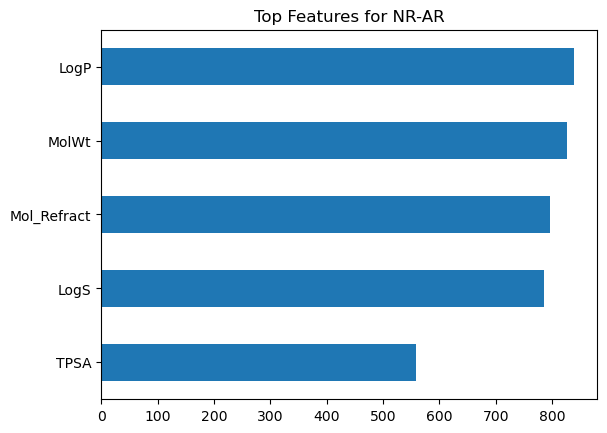

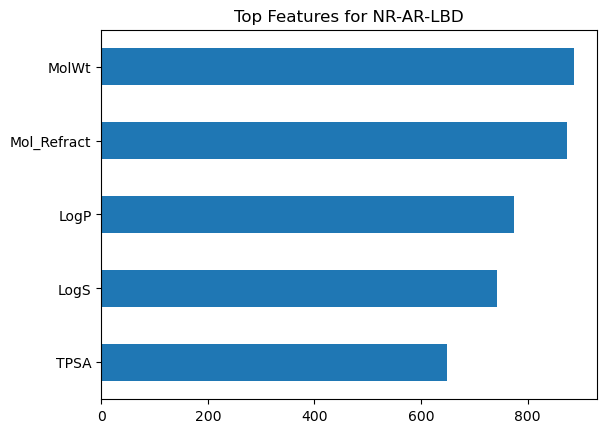

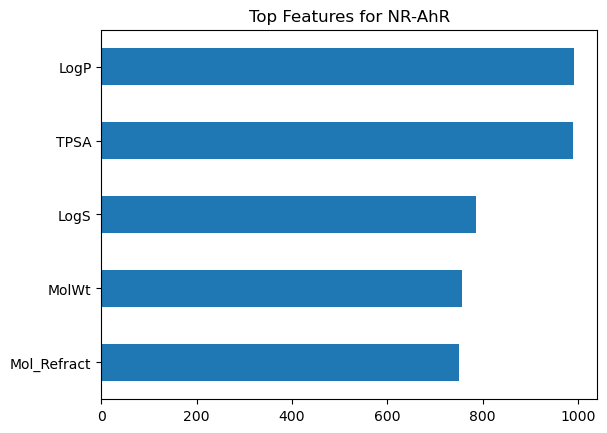

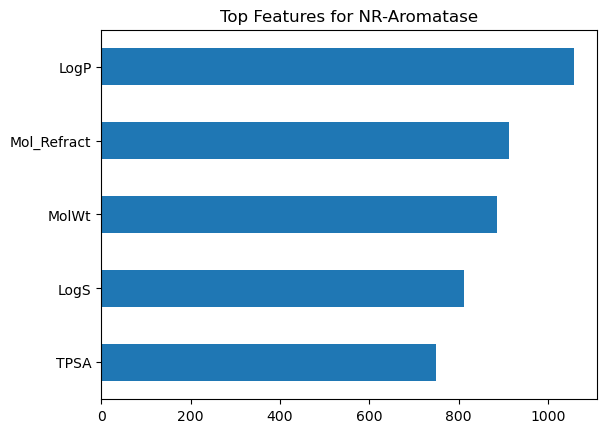

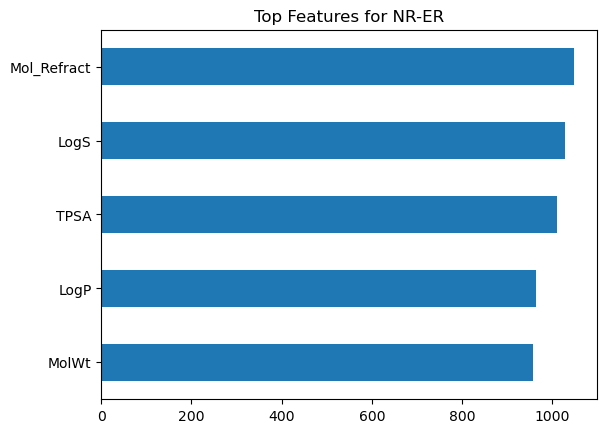

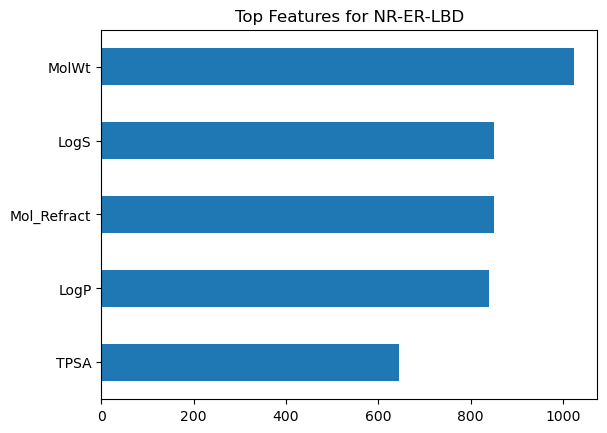

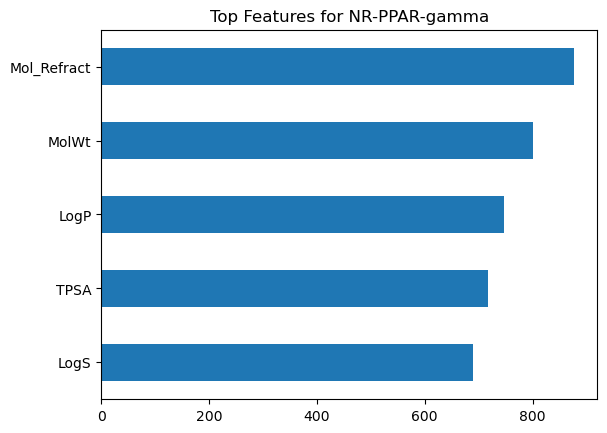

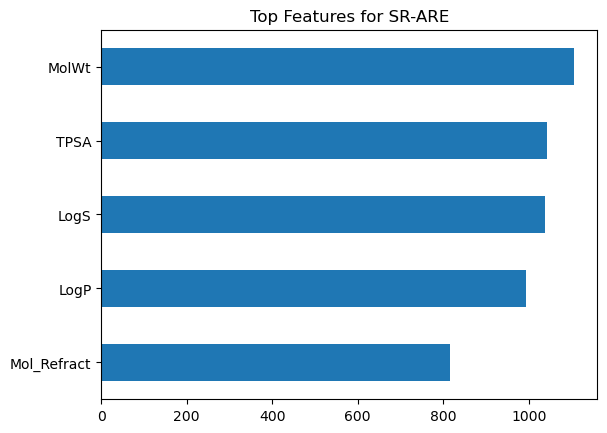

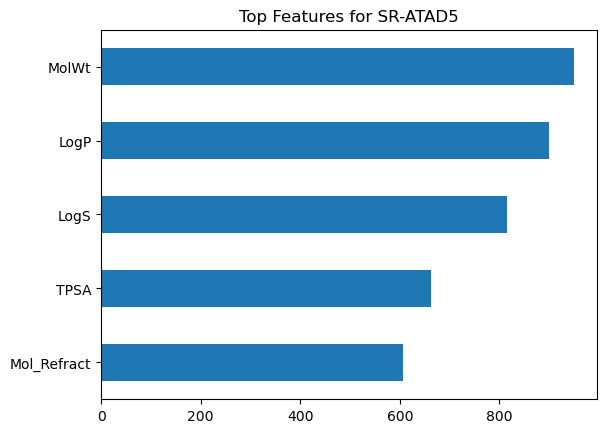

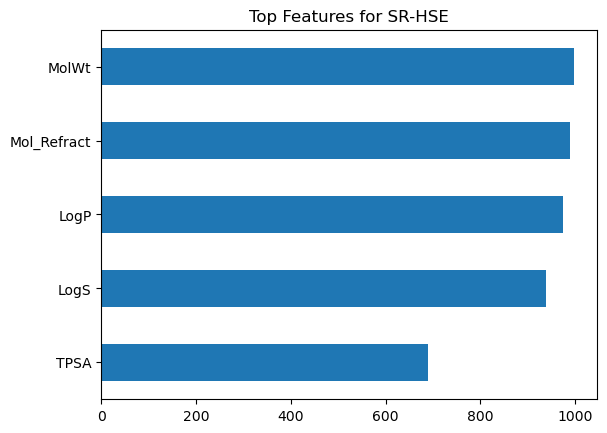

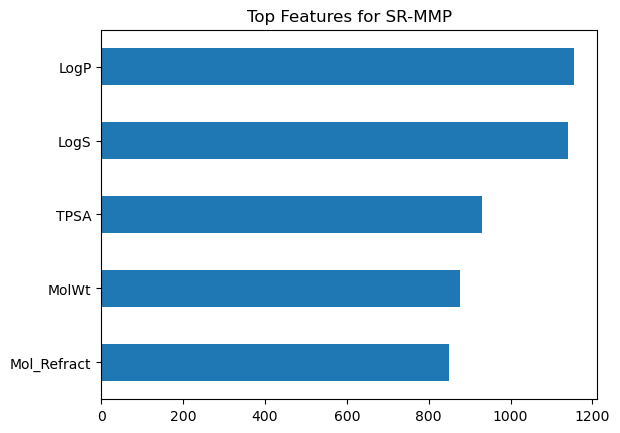

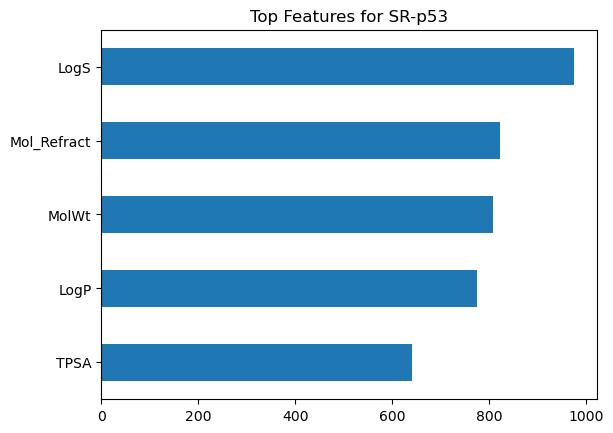

In [31]:
import matplotlib.pyplot as plt

for label in labels:
    top_features_all[label].plot(kind='barh')
    plt.title(f"Top Features for {label}")
    plt.gca().invert_yaxis()
    plt.show()

In [32]:
NR_labels = [col for col in labels if col.startswith('NR')]
SR_labels = [col for col in labels if col.startswith('SR')]

predictions = {}

for label in labels:
    predictions[label] = models[label].predict_proba(X_selected_df)[:, 1]

pred_df = pd.DataFrame(predictions)

pred_df['NR_toxicity'] = pred_df[NR_labels].max(axis=1)
pred_df['SR_toxicity'] = pred_df[SR_labels].max(axis=1)

In [33]:
pred_df

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,NR_toxicity,SR_toxicity
0,0.017683,0.005681,0.964701,0.019177,0.407138,0.010736,0.000399,0.096090,0.002340,0.015766,0.065983,0.066781,0.964701,0.096090
1,0.005388,0.001554,0.024927,0.000615,0.031859,0.001740,0.000355,0.024377,0.022796,0.200308,0.002591,0.063613,0.031859,0.200308
2,0.995582,0.998098,0.007045,0.440037,0.953515,0.987495,0.041681,0.657122,0.000108,0.181898,0.970040,0.013223,0.998098,0.970040
3,0.018419,0.000064,0.079668,0.021388,0.061275,0.010594,0.003655,0.112503,0.000082,0.018512,0.135182,0.005738,0.079668,0.135182
4,0.003371,0.000164,0.001774,0.002824,0.084301,0.011373,0.000022,0.015836,0.000093,0.000461,0.006181,0.008260,0.084301,0.015836
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7818,0.003901,0.000250,0.137958,0.003912,0.005732,0.001406,0.673915,0.380253,0.000149,0.043507,0.670080,0.004936,0.673915,0.670080
7819,0.995181,0.989396,0.003431,0.015810,0.988783,0.689755,0.000042,0.899673,0.000210,0.105313,0.036239,0.105236,0.995181,0.899673
7820,0.999561,0.999617,0.002423,0.021819,0.996794,0.995973,0.001211,0.942996,0.000456,0.030337,0.022015,0.081222,0.999617,0.942996
7821,0.998002,0.999102,0.026386,0.976900,0.998650,0.999591,0.000148,0.128908,0.000252,0.094498,0.984989,0.967918,0.999591,0.984989


C:\Users\noyon\anaconda3\envs\tox21_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\noyon\anaconda3\envs\tox21_env\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


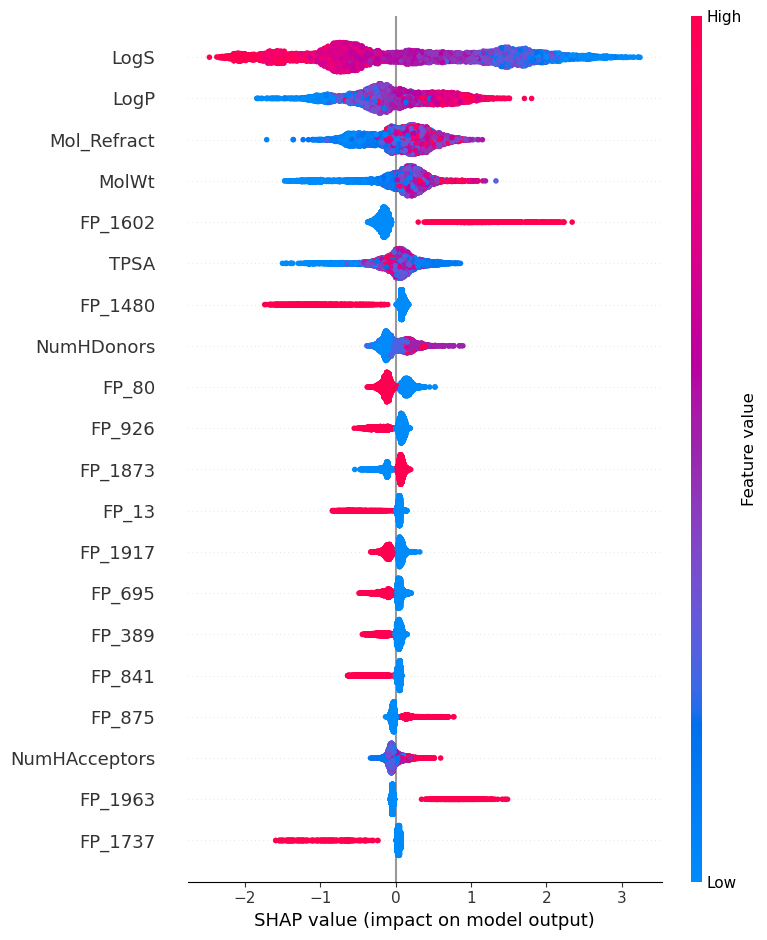

In [34]:
import shap

label = 'SR-MMP'  # best model
model = models[label]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_selected_df)

shap.summary_plot(shap_values, X_selected_df)

In [35]:
import matplotlib.pyplot as plt
import numpy as np

def plot_feature_contributions(X_new, shap_val, feature_names):
    #to get top features
    idx = np.argsort(np.abs(shap_val))[::-1][:10]
    
    features = [feature_names[i] for i in idx]
    values = shap_val[idx]
    
    plt.figure(figsize=(8,5))
    plt.barh(features, values)
    plt.axvline(0)
    plt.title("Top Features Influencing Toxicity")
    plt.xlabel("Impact on Toxicity (SHAP value)")
    plt.gca().invert_yaxis()
    
    plt.show()

In [36]:
def plot_nr_sr(pred_df):
    
    values = [
        pred_df['NR_toxicity'].values[0],
        pred_df['SR_toxicity'].values[0]
    ]
    
    labels = ['NR Toxicity', 'SR Toxicity']
    
    plt.figure(figsize=(5,5))
    plt.bar(labels, values)
    plt.ylim(0,1)
    plt.title("Toxicity Type Comparison")
    
    for i, v in enumerate(values):
        plt.text(i, v + 0.02, f"{v:.2f}", ha='center')
    
    plt.show()

In [37]:
def full_analysis(smiles):
    
    import numpy as np
    import pandas as pd
    import shap
    
    
    #STEP 1: SMILES → FEATURES
    from rdkit.Chem import Draw
    mol = Chem.MolFromSmiles(smiles)
    img=Draw.MolToImage(mol)
    from IPython.display import display
    print("\nGiven Molecule:")
    display(img)
    
    feat = smiles_to_features(smiles)
    
    if feat is None:
        print("❌ Invalid SMILES")
        return
    
    X_new = pd.DataFrame([feat], columns=all_columns)
    
 
    #STEP 2: PREPROCESSING
     
    X_cont = X_new.iloc[:, :num_features]
    X_bin = X_new.iloc[:, num_features:]
    
    X_cont_scaled = scaler.transform(X_cont)
    
    X_processed = np.hstack([X_cont_scaled, X_bin.values])
    
    X_processed_df = pd.DataFrame(X_processed, columns=all_columns)
    
    # Apply variance threshold
    X_selected = selector.transform(X_processed_df)
    
    X_selected_df_new = pd.DataFrame(
        X_selected,
        columns=selected_columns
    )
    
    #STEP 3: ENSEMBLE PREDICTION
    
    predictions = {}
    
    for label in labels:
        
        lgb_pred = models[label].predict_proba(X_selected_df_new)[0][1]
        xgb_pred = xgb_models[label].predict_proba(X_selected_df_new)[0][1]
        
        final_pred = (lgb_pred + xgb_pred) / 2
        
        predictions[label] = final_pred
    
    pred_df = pd.DataFrame([predictions])
   
    #STEP 4: AGGREGATION
    
    NR_labels = [col for col in labels if col.startswith('NR')]
    SR_labels = [col for col in labels if col.startswith('SR')]
    
    pred_df['NR_toxicity'] = pred_df[NR_labels].max(axis=1)
    pred_df['SR_toxicity'] = pred_df[SR_labels].max(axis=1)

    #STEP 5: OUTPUT
    
    threshold = 0.3
    
    print("\n🧪 Toxicity Prediction\n")
    
    print("📊 Individual Endpoints:")
    for label in labels:
        print(f"{label}: {pred_df[label].values[0]:.2f}")
    
    print("\n📊 Aggregated:")
    print(f"NR Toxicity: {pred_df['NR_toxicity'].values[0]:.2f}")
    print(f"SR Toxicity: {pred_df['SR_toxicity'].values[0]:.2f}")
    
    prob = max(pred_df['NR_toxicity'].values[0], pred_df['SR_toxicity'].values[0])
    
    if prob > 0.7:
        print("\n🔴 HIGH RISK")
    elif prob > 0.3:
        print("\n🟠 MODERATE RISK")
    else:
        print("\n🟢 LOW RISK")
 
    #STEP 6: SHAP (LIGHTGBM ONLY)
    
    label = 'SR-MMP'
    model = models[label]
    
    explainer = shap.TreeExplainer(model)
    
    shap_val = explainer.shap_values(X_selected_df_new)[0]
    
    print("\n🧠 Explanation:")
    
    explanations = []
    
    for i in np.argsort(np.abs(shap_val))[::-1][:5]:
        feat_name = X_selected_df.columns[i]
        impact = shap_val[i]
        
        if feat_name == 'LogP':
            explanations.append("High lipophilicity increases toxicity" if impact > 0 else "Low lipophilicity reduces toxicity")
        
        elif feat_name == 'LogS':
            explanations.append("Low solubility increases toxicity" if impact > 0 else "High solubility reduces toxicity")
        
        elif feat_name == 'TPSA':
            explanations.append("Low polarity increases toxicity" if impact > 0 else "High polarity reduces toxicity")
        
        elif "FP_" in feat_name:
            explanations.append(f"Structural fragment ({feat_name}) affects toxicity")
        
        else:
            explanations.append(f"{feat_name} influences toxicity")
    
    for e in explanations:
        print(f"- {e}")

    #STEP 7: VISUALS    
    plot_feature_contributions(X_selected_df_new, shap_val, X_selected_df.columns)
    plot_nr_sr(pred_df)
    
    print("\nDetailed Feature Impact (Waterfall Plot):")
    
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_val,
            base_values=explainer.expected_value,
            data=X_selected_df_new.iloc[0],
            feature_names=X_selected_df.columns
        )
    )
    
    return pred_df


Given Molecule:


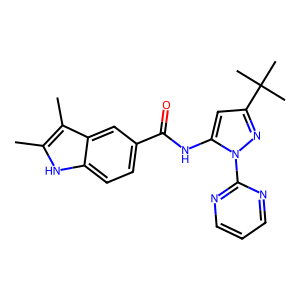


🧪 Toxicity Prediction

📊 Individual Endpoints:
NR-AR: 0.00
NR-AR-LBD: 0.00
NR-AhR: 0.53
NR-Aromatase: 0.37
NR-ER: 0.34
NR-ER-LBD: 0.01
NR-PPAR-gamma: 0.11
SR-ARE: 0.74
SR-ATAD5: 0.01
SR-HSE: 0.03
SR-MMP: 0.80
SR-p53: 0.35

📊 Aggregated:
NR Toxicity: 0.53
SR Toxicity: 0.80

🔴 HIGH RISK


C:\Users\noyon\anaconda3\envs\tox21_env\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(



🧠 Explanation:
- Low solubility increases toxicity
- High lipophilicity increases toxicity
- Structural fragment (FP_1745) affects toxicity
- Mol_Refract influences toxicity
- Structural fragment (FP_1866) affects toxicity


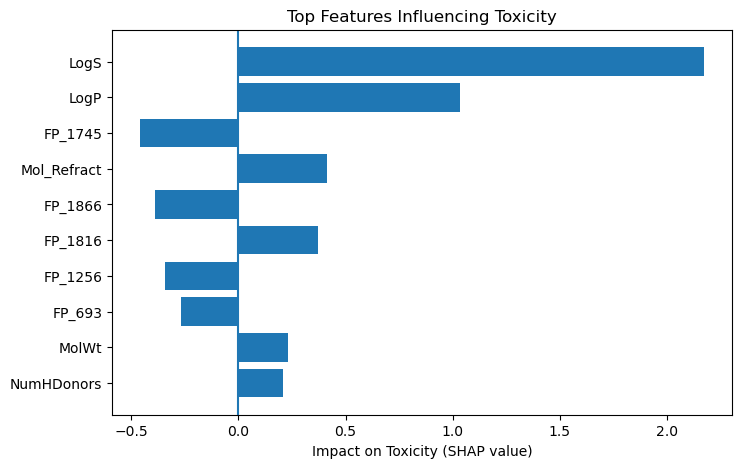

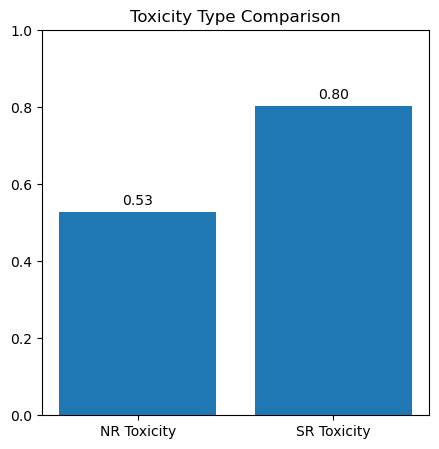


Detailed Feature Impact (Waterfall Plot):


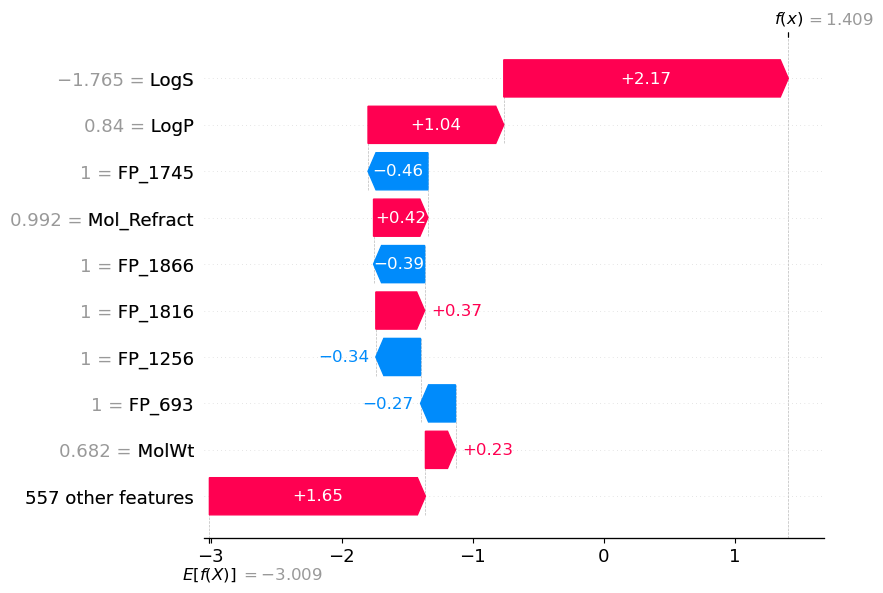

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,NR_toxicity,SR_toxicity
0,0.003383,0.004093,0.527254,0.374783,0.341245,0.01316,0.106114,0.741321,0.009598,0.034871,0.802404,0.350852,0.527254,0.802404


In [38]:
full_analysis("Cc1[nH]c2ccc(C(=O)Nc3cc(C(C)(C)C)nn3-c3ncccn3)cc2c1C")

In [39]:
import pickle

# Create a dictionary of everything needed
pipeline = {
    "models": models,
    "xgb_models": xgb_models,
    "scaler": scaler,
    "selector": selector,
    "selected_columns": selected_columns,
    "all_columns": all_columns,
    "num_features": num_features,
    "labels": labels
}

# Save to file
with open("toxicity_model.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print("✅ Model saved successfully!")

✅ Model saved successfully!
